# Sleep Health and Lifestyle - EDA

## Introduction
- A dataset containing information on people's sleep will be explored to check if a variety of variables affect one's sleep
- Variables include, gender, age, physical activity level, stress, BMI, etc.
- Retrieved dataset from https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

## 1. Discover

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Sleep_health_and_lifestyle_dataset.csv')
df.columns = df.columns.str.replace(' ', '_')
df.head()

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


- renamed columns early since dot-notation may be required during Discover phase

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    str    
 9   Blood_Pressure           374 non-null    str    
 10  Heart_Rate               374 non-null    int64  
 11  Daily_Steps              374 non-null    int64  
 12  Sleep_Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [3]:
df['Sleep_Disorder'].unique()

<StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [4]:
df['Sleep_Disorder'].value_counts()

Sleep_Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [5]:
df['BMI_Category'].unique()

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

In [6]:
df['BMI_Category'].value_counts()

BMI_Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

## 2. Clean

- After viewing data I changed the missing values in "Sleep Disorder" column to "None" to be more in line with the fact that the individual did not exhibit any specific sleep disorder.

In [7]:
df['Sleep_Disorder'] = df['Sleep_Disorder'].fillna('None')
df.head(20)

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None


- Replaces "Normal Weight" to "Normal" to keep consistency

In [8]:
df['BMI_Category'] = df['BMI_Category'].str.replace('Normal Weight', 'Normal')

- Created two new columns, "Systolic BP" and "Diastolic BP", in order to compare blood pressure against other metrics

In [9]:
BP = df['Blood_Pressure'].str.split('/')
df['Systolic_BP'] = BP.str.get(0)
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = BP.str.get(1)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)
df.head()

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


## 3. Verify

In [10]:
df.columns

Index(['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration',
       'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level',
       'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps',
       'Sleep_Disorder', 'Systolic_BP', 'Diastolic_BP'],
      dtype='str')

In [11]:
df['Sleep_Disorder'].value_counts()

Sleep_Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [12]:
df['BMI_Category'].value_counts()

BMI_Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

- checking if the systolic_BP and diastolic_BP columns are of the correct type

In [13]:
df['Systolic_BP'].dtype

dtype('int64')

In [14]:
df['Diastolic_BP'].dtype

dtype('int64')

## 4. Questions

### Section A: Activity and Sleep
- Steps and sleep
    - Does daily steps affect sleep duration?
    - Does daily steps affect quality of sleep?

### Section B: Health Indicators and Sleep Disorder
- BMI/Blood Pressure/Disorder 
    - Is there a relationship between the BMI category and sleep disorders? 
    - Does systolic blood pressure have a relationship with sleep disorders? 
    - Does diastolic blood pressure have a relationship with sleep disorders?

### Section C: Health Indicators and Quality of Sleep
- BMI/Blood Pressure/Disorder vs Quality of sleep
    - Is there correlation between the BMI category and the quality of sleep?
    - Does systolic blood pressure and quality of sleep correlate?
    - Does diastolic blood pressure and quality of sleep correlate?
    - Is there a relationship between sleep disorders and quality of sleep?

## 5. Analysis

### Section A

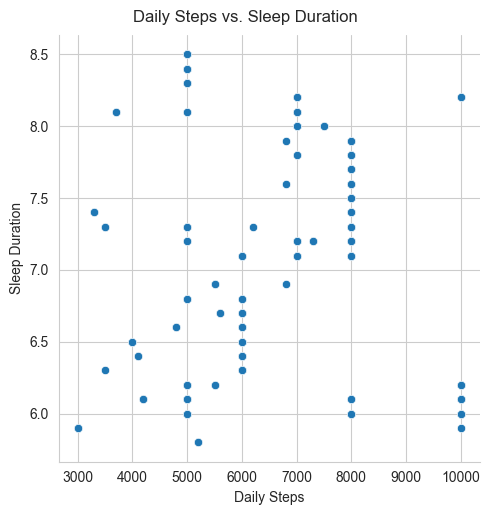

In [23]:
# Daily steps vs sleep duration
sns.set_style('whitegrid')
graph = sns.relplot(data=df, x='Daily_Steps', y='Sleep_Duration', kind='scatter')
graph.figure.suptitle('Daily Steps vs. Sleep Duration', y=1.02)
graph.set(xlabel='Daily Steps', ylabel='Sleep Duration')

In [16]:
df['Daily_Steps'].corr(df['Sleep_Duration'])

np.float64(-0.039532537675731706)

### Finding for Daily Steps vs Sleep Duration
- Correlation score is -0.04 which shows that there is a very weak correlation score.
- Graph is very scattered with no valid shape to show high correlation.

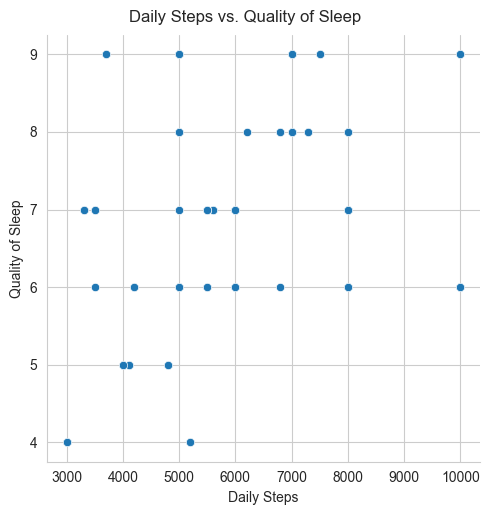

In [22]:
# Daily steps vs quality of sleep
sns.set_style('whitegrid')
graph2 = sns.relplot(data=df, x='Daily_Steps', y='Quality_of_Sleep', kind='scatter')
graph2.figure.suptitle('Daily Steps vs. Quality of Sleep', y=1.02)
graph2.set(xlabel='Daily Steps', ylabel='Quality of Sleep')

In [24]:
df['Daily_Steps'].corr(df['Quality_of_Sleep'])

np.float64(0.01679141492471685)

### Findings for Daily steps vs. Quality of Sleep
- Correlation score is 0.02 which shows a very weak correlation between both variables.
- There is no discernable shape in the graph which fits the weak correlation score

### Section B

In [34]:
# BMI Category vs. Sleep disorders
pd.crosstab(df['BMI_Category'], df['Sleep_Disorder'])

Sleep_Disorder,Insomnia,None,Sleep Apnea
BMI_Category,,,
Normal,9,200,7
Obese,4,0,6
Overweight,64,19,65


Text(0.5, 1.0, 'Sleep Disorder Distribution by BMI Category')

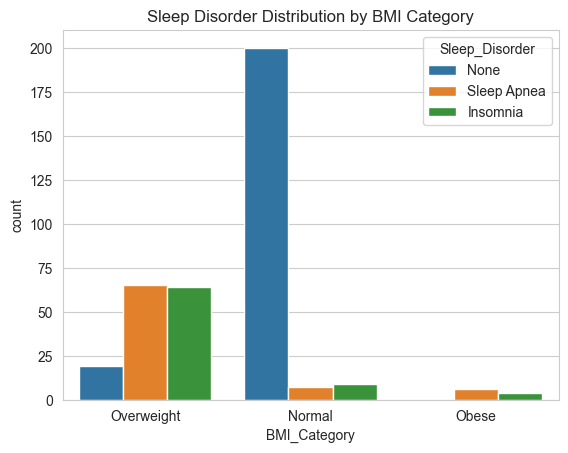

In [37]:
sns.countplot(x='BMI_Category', hue='Sleep_Disorder', data=df)
plt.title('Sleep Disorder Distribution by BMI Category')

### Findings for BMI Category vs. Sleep Disorders
- The overweight group shows the most sleep disorders.
- The obese group does not seem to have anyone within the none category so everyone who is obese within the dataset contains some sort of sleep disorder
- Unequal sample sizes is something to pay attention to. There are more people who make up the normal category than there are in the obese category by a wide margin.

Text(0.5, 1.0, 'Sleep Disorder vs. Systolic Blood Pressure')

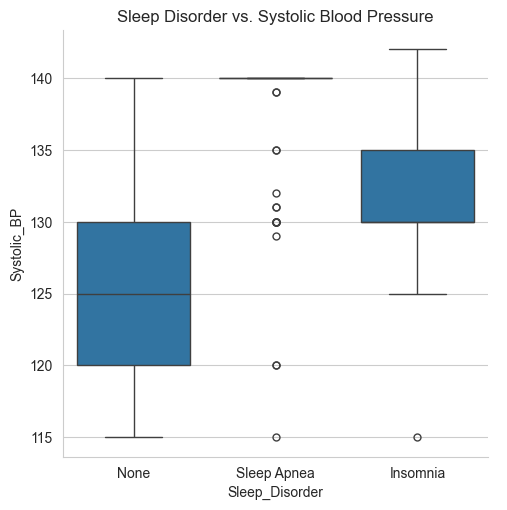

In [39]:
# Systolic BP vs. Sleep Disorder
sns.catplot(data=df, kind='box', x='Sleep_Disorder', y='Systolic_BP')
plt.title('Sleep Disorder vs. Systolic Blood Pressure')

### Findings: Sleep Disorder vs. Systolic Blood Pressure
- Those with insomnia have, on average, a higher systolic blood pressure value
- Those with sleep apnea have a value that clusters at around 140 systolic BP with only a few outliers in a lower range.
- The group with no sleep disorders cover a wide range of systolic blood pressure values but the median is at 125 which is a normal and healthy value.

Text(0.5, 1.0, 'Sleep Disorders vs. Diastolic Blood Pressure')

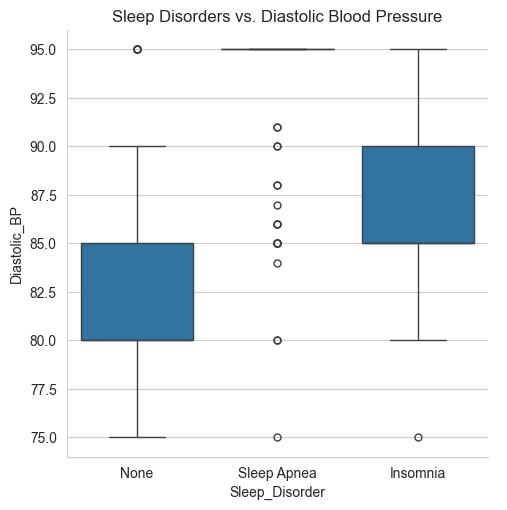

In [42]:
# Diastolic BP vs. Sleep Disorders
sns.catplot(data=df, kind='box', x='Sleep_Disorder', y='Diastolic_BP')
plt.title('Sleep Disorders vs. Diastolic Blood Pressure')

### Findings: Sleep Disorders vs. Diastolic Blood Pressure
- Those with sleep apnea have a tightly clustered Diastolic BP level of 95 with a few outliers below.
- Those with insomnia have a diastolic BP value that ranges from 85.0 and 90.0 which is higher than those with no disorders.
- Those with no disorders have a diastolic BP value that ranges between 80.0 and 85.0, but lower than those with disorders. 

## 6. Conclusion